In [1]:
import pandas as pd
driver=pd.read_csv("drivers.csv")
customer=pd.read_csv("customer.csv")
trip=pd.read_csv("trips.csv")


# Phase 1: Data Understanding

In [2]:
print('Top five driver\n',driver.head())
print('Last five driver\n',driver.tail())
print('Number of rows and columns\n',driver.shape)
print('Name of columns\n',driver.columns)

Top five driver
    driver_id    driver_name  experience_years       city
0          1   Ankit Sharma                12      Delhi
1          2    Mohit Gupta                 3  Prayagraj
2          3  Ankit Agarwal                 2      Noida
3          4   Nitin Sharma                 1     Kanpur
4          5    Arjun Gupta                 9      Noida
Last five driver
      driver_id  driver_name  experience_years       city
195        196  Yash Tiwari                 7  Prayagraj
196        197  Arjun Verma                10  Prayagraj
197        198  Mohit Verma                12      Delhi
198        199  Varun Verma                13      Noida
199        200   Amit Yadav                 9       Agra
Number of rows and columns
 (200, 4)
Name of columns
 Index(['driver_id', 'driver_name', 'experience_years', 'city'], dtype='str')


In [3]:
print("Number of rows and columns\n",customer.shape)
print('Name of columns \n',customer.columns)
print(customer.dtypes)

Number of rows and columns
 (1000, 3)
Name of columns 
 Index(['customer_id', 'customer_name', 'city'], dtype='str')
customer_id      int64
customer_name      str
city               str
dtype: object


In [4]:
print('Number of rows and columns \n', trip.shape)
print('Name of columns \n',trip.columns)
print(trip.dtypes)

Number of rows and columns 
 (10000, 9)
Name of columns 
 Index(['trip_id', 'driver_id', 'customer_id', 'trip_date', 'distance_km',
       'fare_amaount', 'rating', 'vehicle_type', 'pickup_location'],
      dtype='str')
trip_id              int64
driver_id            int64
customer_id          int64
trip_date              str
distance_km        float64
fare_amaount       float64
rating               int64
vehicle_type           str
pickup_location        str
dtype: object


In [5]:
# Stastical Summary
print(trip.describe())

           trip_id     driver_id   customer_id   distance_km  fare_amaount  \
count  10000.00000  10000.000000  10000.000000  10000.000000  10000.000000   
mean    5000.50000    100.849200   1504.015300     21.038355    472.524227   
std     2886.89568     57.597538    288.568562     10.912117    265.750576   
min        1.00000      1.000000   1001.000000      2.010000     31.370000   
25%     2500.75000     51.000000   1257.000000     11.557500    252.777500   
50%     5000.50000    101.000000   1507.000000     21.090000    454.995000   
75%     7500.25000    151.000000   1754.000000     30.380000    660.425000   
max    10000.00000    200.000000   2000.000000     40.000000   1189.760000   

             rating  
count  10000.000000  
mean       3.005400  
std        1.411513  
min        1.000000  
25%        2.000000  
50%        3.000000  
75%        4.000000  
max        5.000000  


In [6]:
trip.isnull()

,trip_id,driver_id,customer_id,trip_date,distance_km,fare_amaount,rating,vehicle_type,pickup_location
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False


In [7]:
trip.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

In [8]:
print(trip.memory_usage())
print(trip.memory_usage().sum())

Index                132
trip_id            80000
driver_id          80000
customer_id        80000
trip_date          80000
distance_km        80000
fare_amaount       80000
rating             80000
vehicle_type       80000
pickup_location    80000
dtype: int64
720132


# Phase 2: Data Cleaning

In [9]:
print(trip['trip_date'].dtypes)
trip['trip_date']=pd.to_datetime(trip['trip_date'])


str


In [10]:
trip['trip_date'].dtypes

dtype('<M8[us]')

# Phase 4: Basic Analysis

### Total Revenue.

In [11]:
print(trip['fare_amaount'].sum())

4725242.2700000005


### Average Fare.

In [12]:
print(trip['fare_amaount'].mean())

472.52422700000005


### Highest Fare.

In [13]:
print(trip['fare_amaount'].max())

1189.76


### Average Distance.

In [14]:
print(trip['distance_km'].mean())

21.038355


### Maximum Distance.

In [15]:
print(trip['distance_km'].max())

40.0


### Minimum Distance.

In [16]:
print(trip['distance_km'].min())

2.01


### Total Trips.

In [17]:
print(trip['distance_km'].count())

10000


### Highest Rating Count.

In [18]:
print(trip['rating'].max())

5


# Phase 5: Vehicle Analysis

### Vehicle-wise Revenue.

In [19]:
trip.groupby('vehicle_type')['fare_amaount'].sum()

vehicle_type
Hatchback    1157585.43
Mini         1197425.82
SUV          1179676.78
Sedan        1190554.24
Name: fare_amaount, dtype: float64

### Vehicle-wise Average Fare.

In [20]:
trip.groupby('vehicle_type')['fare_amaount'].mean()

vehicle_type
Hatchback    477.354816
Mini         471.613163
SUV          469.616553
Sedan        471.693439
Name: fare_amaount, dtype: float64

### Vehicle-wise Average Rating.

In [21]:
trip.groupby('vehicle_type')['rating'].mean()

vehicle_type
Hatchback    2.996289
Mini         3.014573
SUV          3.004777
Sedan        3.005547
Name: rating, dtype: float64

### Vehicle-wise Total Trips.

In [22]:
trip.groupby('vehicle_type')['trip_id'].count()

vehicle_type
Hatchback    2425
Mini         2539
SUV          2512
Sedan        2524
Name: trip_id, dtype: int64

### Most Profitable Vehicle.

In [23]:
print(trip.groupby('vehicle_type')['fare_amaount'].sum().sort_values(ascending=False).head(1))

vehicle_type
Mini    1197425.82
Name: fare_amaount, dtype: float64


### Most Used Vehicle.

In [24]:
trip.groupby('vehicle_type')['trip_id'].count().sort_values(ascending=False).head(1)

vehicle_type
Mini    2539
Name: trip_id, dtype: int64

### Least Used Vehicle.

In [25]:
trip.groupby('vehicle_type')['trip_id'].count().sort_values(ascending=True).head(1)

vehicle_type
Hatchback    2425
Name: trip_id, dtype: int64

### Vehicle-wise Fare Per KM.

In [26]:
trip.groupby('vehicle_type')['fare_amaount'].sum()/trip.groupby('vehicle_type')['distance_km'].sum()

vehicle_type
Hatchback    22.360081
Mini         22.479930
SUV          22.576405
Sedan        22.423395
dtype: float64

### Vehicle-wise Revenue Percentage.

In [27]:
(trip.groupby('vehicle_type')['fare_amaount'].sum()/trip['fare_amaount'].sum())*100

vehicle_type
Hatchback    24.497906
Mini         25.341046
SUV          24.965424
Sedan        25.195623
Name: fare_amaount, dtype: float64

# Phase 6: Location Analysis

### City-wise Revenue.

In [28]:
trip.groupby('pickup_location')['fare_amaount'].sum()

pickup_location
Agra         788149.19
Delhi        777735.74
Kanpur       781805.64
Lucknow      772277.03
Noida        813790.29
Prayagraj    791484.38
Name: fare_amaount, dtype: float64

### City-wise Trip Count.

In [29]:
trip.groupby('pickup_location')['trip_id'].count()

pickup_location
Agra         1684
Delhi        1651
Kanpur       1661
Lucknow      1653
Noida        1687
Prayagraj    1664
Name: trip_id, dtype: int64

### City-wise Average Fare.

In [30]:
trip.groupby('pickup_location')['fare_amaount'].sum()

pickup_location
Agra         788149.19
Delhi        777735.74
Kanpur       781805.64
Lucknow      772277.03
Noida        813790.29
Prayagraj    791484.38
Name: fare_amaount, dtype: float64

### City-wise Average Rating.

In [31]:
trip.groupby('pickup_location')['rating'].mean()

pickup_location
Agra         3.024941
Delhi        2.990309
Kanpur       3.006020
Lucknow      3.026013
Noida        2.965619
Prayagraj    3.019832
Name: rating, dtype: float64

### Most Profitable City.

In [32]:
trip.groupby('pickup_location')['fare_amaount'].sum().sort_values(ascending=False).head(1)

pickup_location
Noida    813790.29
Name: fare_amaount, dtype: float64

### Least Profitable City.

In [33]:
trip.groupby('pickup_location')['fare_amaount'].sum().sort_values().head(1)

pickup_location
Lucknow    772277.03
Name: fare_amaount, dtype: float64

### Highest Rated City.

In [34]:
trip.groupby('pickup_location')['rating'].mean().sort_values(ascending=False).head(1)

pickup_location
Lucknow    3.026013
Name: rating, dtype: float64

### Lowest Rated City.

In [35]:
trip.groupby('pickup_location')['rating'].mean().sort_values().head(1)

pickup_location
Noida    2.965619
Name: rating, dtype: float64

### Revenue Share by City.

In [36]:
(trip.groupby('pickup_location')['fare_amaount'].sum()/trip['fare_amaount'].sum())*100

pickup_location
Agra         16.679551
Delhi        16.459172
Kanpur       16.545303
Lucknow      16.343649
Noida        17.222192
Prayagraj    16.750133
Name: fare_amaount, dtype: float64

# Phase 7: Driver Analysis

### Trips aur Drivers merge karo.

In [37]:
pd.merge(trip, driver, on='driver_id')

,trip_id,driver_id,customer_id,trip_date,distance_km,fare_amaount,rating,vehicle_type,pickup_location,driver_name,experience_years,city
0,1,74,1795,2025-04-28,36.60,958.10,5,Hatchback,Lucknow,Ankit Sharma,11,Noida
1,2,174,1774,2025-12-04,26.19,636.77,2,Sedan,Prayagraj,Nitin Agarwal,12,Prayagraj
2,3,113,1035,2025-10-24,26.56,521.48,3,SUV,Kanpur,Nitin Singh,1,Delhi
3,4,107,1180,2025-04-13,36.57,727.77,2,Hatchback,Noida,Nitin Mishra,1,Kanpur
4,5,43,1264,2025-09-04,21.07,402.18,3,Hatchback,Kanpur,Ayush Verma,14,Prayagraj
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,129,1973,2025-07-05,3.52,70.90,3,Hatchback,Noida,Deepak Sharma,2,Noida
9996,9997,151,1101,2025-11-22,21.01,625.56,5,Sedan,Lucknow,Pankaj Tiwari,15,Prayagraj
9997,9998,176,1956,2025-05-10,37.38,825.20,3,Hatchback,Noida,Aditya Gupta,5,Agra
9998,9999,195,1792,2025-02-23,14.71,376.04,1,Sedan,Lucknow,Yash Sharma,15,Delhi


###  Customer-wise Spending.

In [38]:
trip.groupby('customer_id')['fare_amaount'].sum()


customer_id
1001    3539.32
1002    3157.95
1003    6844.34
1004    4026.61
1005    2890.12
         ...   
1996    5831.68
1997    3474.88
1998    6001.11
1999    2334.75
2000    4044.08
Name: fare_amaount, Length: 1000, dtype: float64

### Customer-wise Trip Count.

In [39]:
merge=pd.merge(trip, customer, on='customer_id', how='inner')
merge.groupby('customer_name')['trip_id'].count()

customer_name
Abhishek Agarwal    103
Abhishek Gupta       60
Abhishek Jain        19
Abhishek Mishra      36
Abhishek Pandey      48
                   ... 
Yash Sharma          58
Yash Singh           22
Yash Tiwari          51
Yash Verma           12
Yash Yadav           49
Name: trip_id, Length: 198, dtype: int64

### Top Spending Customer.

In [40]:
merge.groupby('customer_name')['fare_amaount'].sum().sort_values(ascending=False).head(1)

customer_name
Vivek Singh    58065.6
Name: fare_amaount, dtype: float64

### Top 10 Customers.

In [41]:
merge.groupby('customer_name')['fare_amaount'].sum().sort_values(ascending=False).head(10)

customer_name
Vivek Singh         58065.60
Karan Agarwal       54491.51
Vikas Pandey        54489.10
Saurabh Verma       52571.03
Aditya Verma        48458.04
Saurabh Tiwari      48139.37
Karan Singh         46720.31
Vivek Jain          46109.68
Manish Sharma       45463.26
Abhishek Agarwal    44914.36
Name: fare_amaount, dtype: float64

### Customer Retention Analysis.

In [42]:
customer_trip=trip.groupby('customer_id')['trip_id'].count()
retained_customer=customer_trip[customer_trip>1]
total_customer=customer['customer_id'].count()
retained_rate=(retained_customer/total_customer)*100
print(retained_rate)

customer_id
1001    0.8
1002    0.9
1003    1.3
1004    0.9
1005    0.8
       ... 
1996    1.1
1997    0.7
1998    1.6
1999    0.5
2000    1.0
Name: trip_id, Length: 998, dtype: float64


### Average Spend Per Customer.

In [43]:
total_customer=customer['customer_id'].nunique()
total_spend=trip['fare_amaount'].sum()
avg_spend_pr_cust=total_spend/total_customer
print(avg_spend_pr_cust)

4725.242270000001


### Highest Trip Count Customer.

In [44]:
trip_cust=pd.merge(trip, customer, on='customer_id')
trip_count=trip_cust.groupby(['customer_id','customer_name'])['fare_amaount'].count()
print(trip_count.sort_values(ascending=False).head(1))


customer_id  customer_name
1308         Amit Pandey      20
Name: fare_amaount, dtype: int64


### Revenue Contribution of Top 10 Customers.

In [45]:
revenue_count=trip_cust.groupby(['customer_id','customer_name'])['fare_amaount'].sum()
print(revenue_count.sort_values(ascending=False).head(10).sum())

94791.94


# Phase 9: Time Series Analysis

### Month-wise Revenue.

In [46]:
trip_cust['month'] = trip_cust['trip_date'].dt.month_name()
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

trip_cust['month'] = pd.Categorical(
    trip_cust['month'],
    categories=month_order,
    ordered=True
)
trip_cust.groupby('month')['fare_amaount'].sum()

month
January      379302.41
February     369765.15
March        405721.66
April        402574.16
May          386293.29
June         387999.09
July         413180.86
August       410952.76
September    379681.00
October      393461.65
November     371951.84
December     424358.40
Name: fare_amaount, dtype: float64

### Month-wise Trips.

In [47]:
trip_cust.groupby('month')['trip_id'].count()

month
January      829
February     800
March        835
April        837
May          822
June         819
July         860
August       864
September    801
October      851
November     788
December     894
Name: trip_id, dtype: int64

### Month-wise Average Fare.

In [48]:
trip_cust.groupby('month')['fare_amaount'].mean()

month
January      457.542111
February     462.206438
March        485.894204
April        480.972712
May          469.943175
June         473.747363
July         480.442860
August       475.639769
September    474.008739
October      462.352115
November     472.020102
December     474.673826
Name: fare_amaount, dtype: float64

### Month-wise Rating.

In [49]:
trip_cust.groupby('month')['rating'].mean()

month
January      2.996381
February     2.966250
March        3.037126
April        2.972521
May          2.939173
June         3.003663
July         2.967442
August       2.979167
September    3.083645
October      3.051704
November     3.079949
December     2.994407
Name: rating, dtype: float64

### Best Revenue Month.

In [50]:
print(trip_cust.groupby('month')['fare_amaount'].sum().sort_values(ascending=False).head(1))

month
December    424358.4
Name: fare_amaount, dtype: float64


### Worst Revenue Month.

In [51]:
print(trip_cust.groupby('month')['fare_amaount'].sum().sort_values(ascending=False).tail(1))

month
February    369765.15
Name: fare_amaount, dtype: float64


### Revenue Growth Rate.

In [52]:
# Date ko datetime me convert karo
trip['trip_date'] = pd.to_datetime(trip['trip_date'])

# Month nikalo
trip['month'] = trip['trip_date'].dt.to_period('M')

# Month-wise revenue
monthly_revenue = trip.groupby('month')['fare_amaount'].sum().reset_index()

# Previous month revenue
monthly_revenue['previous_revenue'] = monthly_revenue['fare_amaount'].shift(1)

# Revenue Growth Rate (%)
monthly_revenue['growth_rate'] = (
    (monthly_revenue['fare_amaount'] - monthly_revenue['previous_revenue'])
    / monthly_revenue['previous_revenue']
) * 100

print(monthly_revenue)

      month  fare_amaount  previous_revenue  growth_rate
0   2025-01     379302.41               NaN          NaN
1   2025-02     369765.15         379302.41    -2.514421
2   2025-03     405721.66         369765.15     9.724148
3   2025-04     402574.16         405721.66    -0.775778
4   2025-05     386293.29         402574.16    -4.044192
5   2025-06     387999.09         386293.29     0.441582
6   2025-07     413180.86         387999.09     6.490162
7   2025-08     410952.76         413180.86    -0.539255
8   2025-09     379681.00         410952.76    -7.609575
9   2025-10     393461.65         379681.00     3.629534
10  2025-11     371951.84         393461.65    -5.466812
11  2025-12     424358.40         371951.84    14.089609


# Phase 10: Advanced Pandas

### Pivot Table: Vehicle vs Revenue.

In [53]:
pd.pivot_table(
    data=trip,
    index='vehicle_type',
    values='fare_amaount',
    aggfunc='sum'
)

,fare_amaount
vehicle_type,
Hatchback,1157585.43
Mini,1197425.82
SUV,1179676.78
Sedan,1190554.24


# Phase 11: Matplotlib

### Vehicle Revenue Bar Chart.

In [54]:
import matplotlib.pyplot as plt

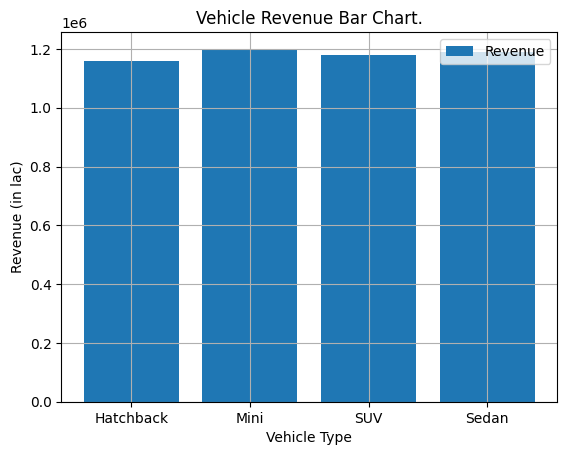

In [93]:
vehicle_revenue=trip.groupby('vehicle_type')['fare_amaount'].sum().reset_index()
plt.bar(vehicle_revenue['vehicle_type'],vehicle_revenue['fare_amaount'],label='Revenue')
plt.xlabel('Vehicle Type')
plt.ylabel('Revenue (in lac)')
plt.title('Vehicle Revenue Bar Chart.')
plt.grid()
plt.legend()
plt.savefig("Veh_Rev_Bar.png")
plt.show()

# Vehicle-wise Revenue

## Insight:

#### This bar chart compares the total revenue generated by each vehicle type.
#### Mini generated the highest revenue (₹1,197,425.82).
#### Sedan is the second-highest revenue generator (₹1,190,554.24).
#### SUV generated ₹1,179,676.78.
#### Hatchback generated the lowest revenue (₹1,157,585.43).
#### The revenue difference between all vehicle types is relatively small, indicating that each vehicle category contributes almost equally to the overall revenue.

## City-wise Revenue

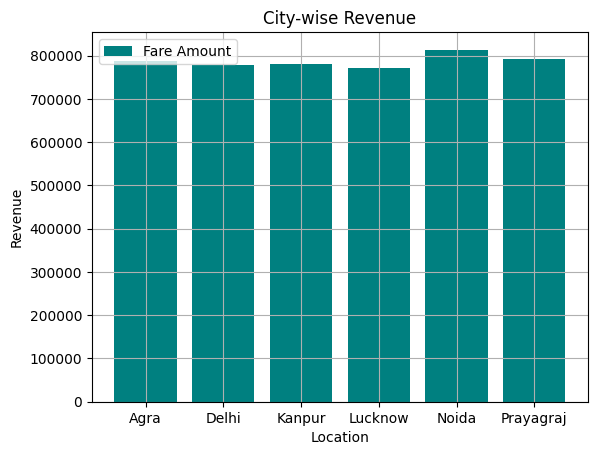

In [94]:
city_revenue=trip.groupby('pickup_location')['fare_amaount'].sum().reset_index()
city_revenue
plt.bar(city_revenue['pickup_location'],city_revenue['fare_amaount'],label='Fare Amount',color='teal')
plt.xlabel('Location')
plt.ylabel('Revenue')
plt.title('City-wise Revenue')
plt.grid()
plt.legend()
plt.savefig('City_W_Rev_bar.png')
plt.show()


## Insight:

#### This bar chart compares the total revenue generated from different pickup cities.
#### Noida generated the highest revenue (₹813,790.29), making it the top-performing city.
#### Prayagraj (₹791,484.38) and Agra (₹788,149.19) are the next highest revenue contributors.
#### Delhi (₹777,735.74) and Kanpur (₹781,805.64) generated moderate revenue.
#### Lucknow generated the lowest revenue (₹772,277.03).
#### Overall, the revenue difference among cities is relatively small, indicating that revenue is fairly evenly distributed across all pickup locations.

## Monthly Revenue

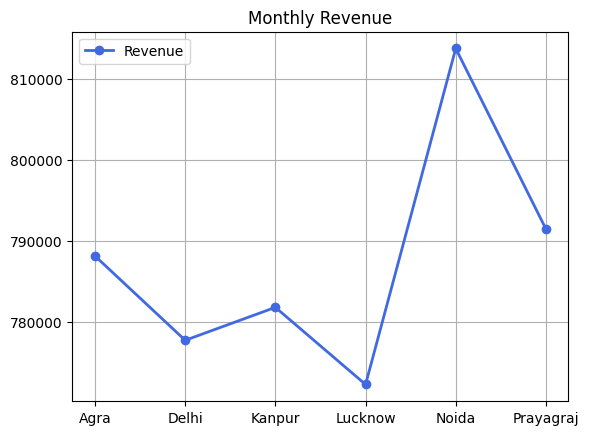

In [95]:
monthly_revenue=trip_cust.groupby('month')['fare_amaount'].sum()

plt.plot(
    city_revenue['pickup_location'],
    city_revenue['fare_amaount'],
    marker='o',
    linestyle='-',
    color='royalblue',
    label='Revenue',
    linewidth=2
)
plt.title('Monthly Revenue')
plt.grid()
plt.legend()
plt.savefig('Mont_Rev_line.png')
plt.show()



## Insight:

#### This line chart shows the monthly revenue trend throughout the year.
#### December generated the highest revenue (₹424,358.40), indicating the strongest business performance.
#### July (₹413,180.86) and August (₹410,952.76) also recorded high revenue.
#### February generated the lowest revenue (₹369,765.15), followed by November (₹371,951.84).
#### Overall, revenue remained relatively stable across the year, with noticeable growth during July–August and a peak in December.

## Fare Distribution

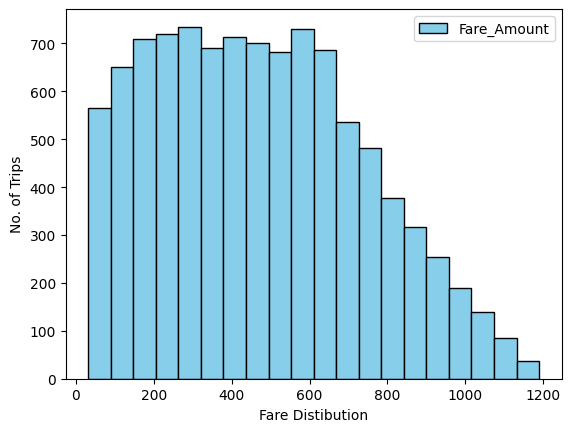

In [96]:
plt.hist(
    trip['fare_amaount'],
    bins=20,
    color='skyblue',
    edgecolor='black',
    label='Fare_Amount'
)
plt.xlabel('Fare Distibution')
plt.ylabel('No. of Trips')
plt.legend()
plt.savefig('Fare_Dist_His.png')
plt.show()

## Insight:

#### This histogram shows how trip fares are distributed across different fare ranges.
#### Most trips are concentrated in the lower to medium fare ranges, indicating that customers usually take short- to medium-distance rides.
#### As the fare amount increases, the number of trips gradually decreases, meaning high-fare trips are less frequent.
#### This distribution helps identify the most common fare range and highlights the presence of any unusually high or low fare values.

## Distance vs Fare

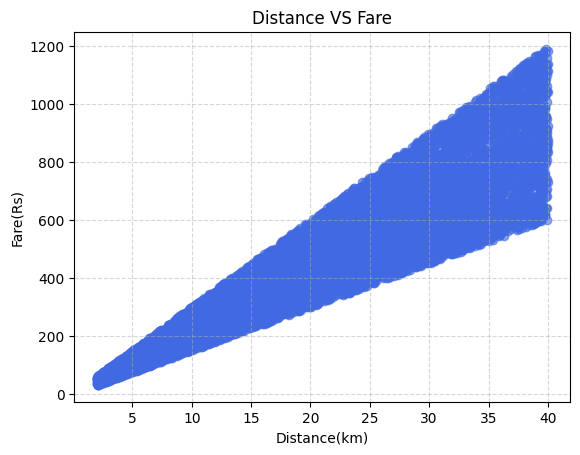

In [97]:
plt.scatter(trip['distance_km'],trip['fare_amaount'],    color='royalblue',alpha=0.6)
plt.title('Distance VS Fare')
plt.xlabel('Distance(km)')
plt.ylabel('Fare(Rs)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('Dist_VS_Fare_scatter.png')
plt.show()

## Insight:

#### This scatter plot shows the relationship between trip distance and fare amount.
#### There is a positive correlation between distance and fare, meaning that as the trip distance increases, the fare generally increases as well.
#### Most trips are concentrated in the short- to medium-distance range with moderate fares.
#### A few points with unusually high fares or long distances may represent long trips or premium rides.

## Vehicle-wise Average Rating

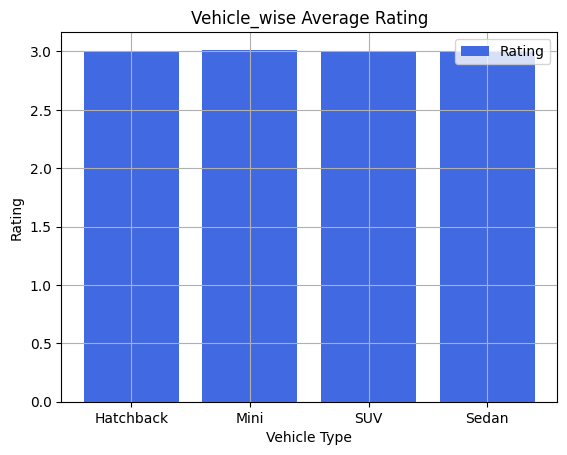

In [98]:
rating_count=trip.groupby('vehicle_type')['rating'].mean().reset_index()
plt.bar(rating_count['vehicle_type'],rating_count['rating'],label='Rating',color='royalblue')
plt.xlabel('Vehicle Type')
plt.ylabel('Rating')
plt.title('Vehicle_wise Average Rating')
plt.grid()
plt.legend()
plt.savefig('Veh_W_Avg_Rat_bar.png')
plt.show()


## Insight:

#### This bar chart compares the average customer rating for each vehicle type.
#### Mini has the highest average rating, indicating the highest level of customer satisfaction.
#### Hatchback has the lowest average rating among the vehicle categories.
#### The ratings of all vehicle types are relatively close, suggesting that customers are generally satisfied across all vehicle categories.

## Revenue Share by City

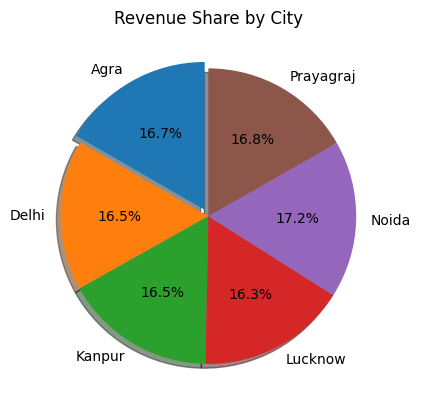

In [99]:
city_revenue = trip.groupby('pickup_location')['fare_amaount'].sum().reset_index()

plt.pie(
    city_revenue['fare_amaount'],
    labels=city_revenue['pickup_location'],
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    explode=(0.05,0,0,0,0,0)
)
plt.title('Revenue Share by City')
plt.savefig('Rev_Shar_City_pie.png')

plt.show()

## Insight:

#### This pie chart shows the percentage contribution of each pickup city to the total revenue.
#### Noida contributes the largest share of revenue, making it the highest revenue-generating city.
#### Lucknow contributes the smallest share among the listed cities.
#### The revenue shares of Agra, Delhi, Kanpur, and Prayagraj are quite similar, indicating balanced business performance across these locations.
#### Overall, no single city dominates the total revenue, suggesting that the company's revenue is well distributed across multiple cities.